<a href="https://colab.research.google.com/github/ikeyareinaldosae/ITC501---Artificial-Intelligence-Applications/blob/main/Week_3_Bivariate_Analysis_Pt_1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 3 Lab (Task 1) - Bivariate Analysis: Continuous vs Categorical**

### What is bivariate analysis?

Bivariate analysis is a statistical technique that encompasses exploring the relationship between two variables. Bivariate analysis can be implemented when a variable is continuous and another is categorical, in which we are then able to determine if there is a difference in the distribution of the continuous variable for each category of the categorical variable.

## Import Libraries

In [5]:
import plotly.express as px
import plotly.graph_objs as go
import numpy as np
import pandas as pd

## Mount the google drive and Read in data

For the next few examples, we will be using a customer churn dataset that details whether individuals have left a company or not

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
data_folder = "drive/MyDrive/datasets"

churn = pd.read_csv(f"{data_folder}/churn.csv")
churn.head()

Mounted at /content/drive


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,Yes,Yes,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,No,Yes,112542.58,0
2,502,France,Female,42,8,159660.80,3,Yes,No,113931.57,1
3,699,France,Female,39,1,0.00,2,No,No,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,Yes,Yes,79084.10,0


In [4]:
churn.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

## Bivariate Boxplots

We expand our work from the first chapter and this time group our plots by category. We will start by demonstrating how bivariate box-plots can be implemented using both `plotly.express` and `plotly.graph_objs`. With `plotly.express` we still pass in our `data_frame` as usual. The only difference now is that we pass in `x` and `y` as keyword arguments (we can choose which variable takes on which axis).

For example, we can create a bivariate boxplot using:

```
fig = px.box(data_frame=churn, x='Geography', y='Age')
fig.show()
```

It is also worth noting that you can in fact plot without passing in the `data_frame` argument. Here we refer to the column/series explicitly like we have done in Plotly Graph Objects. It is really up to you which way you prefer:

```
fig = px.box(x=churn['Geography'], y=churn['Age'])
fig.show()
```

---

With `plotly.graph_objs` objects, the process is very similar to the univariate case. One difference is that we pass in both `x` and `y` as arguments for our trace since we are now dealing with two variables

## Bivariate Boxplot: Plotly Express

Let's now use what we know about boxplots to plot the distribution of peoples ages grouped in terms of country (`Geography`)

In [6]:
fig = px.box(data_frame=churn, x='Geography', y='Age')
fig.show()

### Your Turn

Your Task

Extend the given code to enhance the box plot with additional features or data. Consider the following ideas for extending the plot:

* Color by Gender: Modify the box plot to include a color dimension based on the Gender column.
* Facet by Another Variable: Create multiple box plots faceted by another categorical variable like HasCrCard or IsActiveMember.

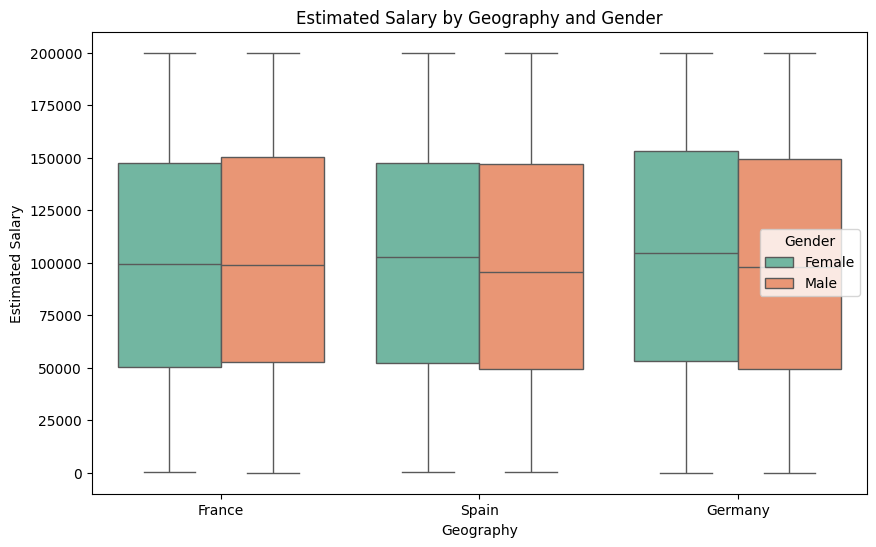

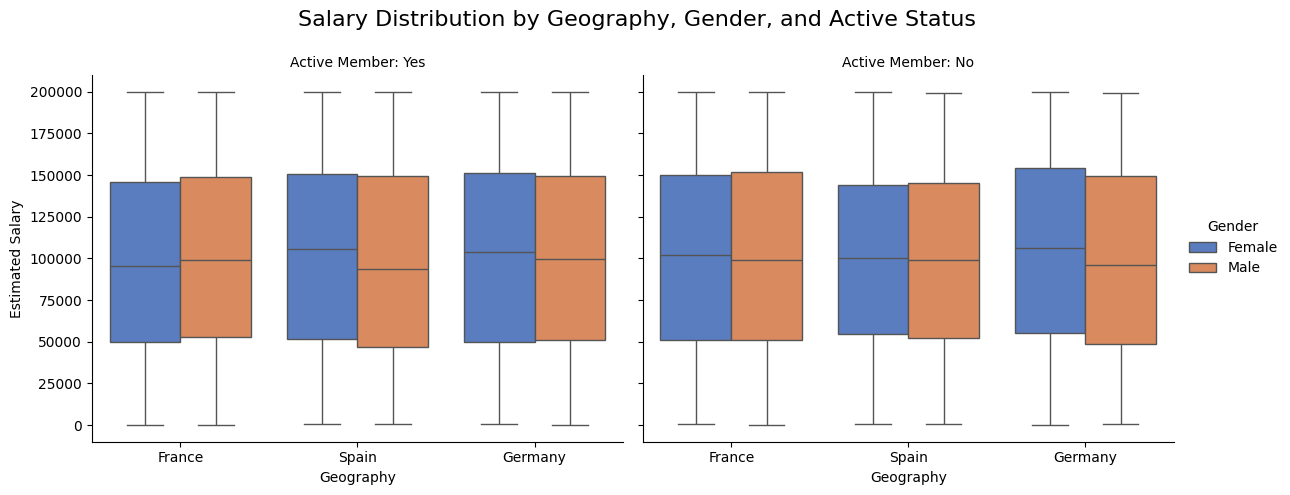

In [9]:
#Provide your answer with clear documentation that demonstrate a proper understanding of how the code works.

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'EstimatedSalary' is the numeric variable you are plotting against 'Geography'
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=churn,
    x='Geography',
    y='EstimatedSalary',
    hue='Gender',
    palette='Set2'
)

plt.title('Estimated Salary by Geography and Gender')
plt.xlabel('Geography')
plt.ylabel('Estimated Salary')
plt.legend(title='Gender')
plt.show()


# catplot creates a grid of plots. kind='box' specifies a box plot.
g = sns.catplot(
    data=churn,
    x='Geography',
    y='EstimatedSalary',
    hue='Gender',
    col='IsActiveMember',  # This creates one subplot per category of IsActiveMember
    kind='box',
    palette='muted',
    height=5,
    aspect=1.2
)

# Adjust titles and layout
g.set_titles("Active Member: {col_name}")
g.set_axis_labels("Geography", "Estimated Salary")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Salary Distribution by Geography, Gender, and Active Status', fontsize=16)

plt.show()

## **Histogram**

### What is Histogram?

A histogram is a type of graph used to show the distribution of numerical data. It groups numbers into ranges called bins and shows how many values fall into each range.

### Advantages
*   Shows the distribution of data
*   Easy to identify patterns
*   Helps detect outliers

### Disadvantages
*   Loss of exact values
*   Choice of bin size affects the graph
*   Not suitable for categorical data
*   List item









## Histograms (Continuous vs Categorical): Plotly Express

When plotting a histogram in `plotly.express` involving more than one variable, we can set the `color` argument as a string representing the column that we wish to colour in terms of. In this example, we plot the age of individuals and group it per country. We've also set `histnorm='probability density'` to set the $y$ axis values to represent the probability density and not the count of the number of values in each bar.

In [10]:
fig = px.histogram(data_frame=churn,
                   x='Age',
                   color='Geography',
                   histnorm='probability density')
fig.show()

### **Your Turn**

Extend the given histogram to include additional features or data that provide more insights. Here are two ideas for extending the plot:

* Facet by Gender: Create multiple histograms faceted by the Gender column to see how age distribution varies across genders in different geographical regions.
* Binning by Tenure: Adjust the bin sizes to reflect Tenure categories, allowing for analysis of age distribution within different tenure groups.

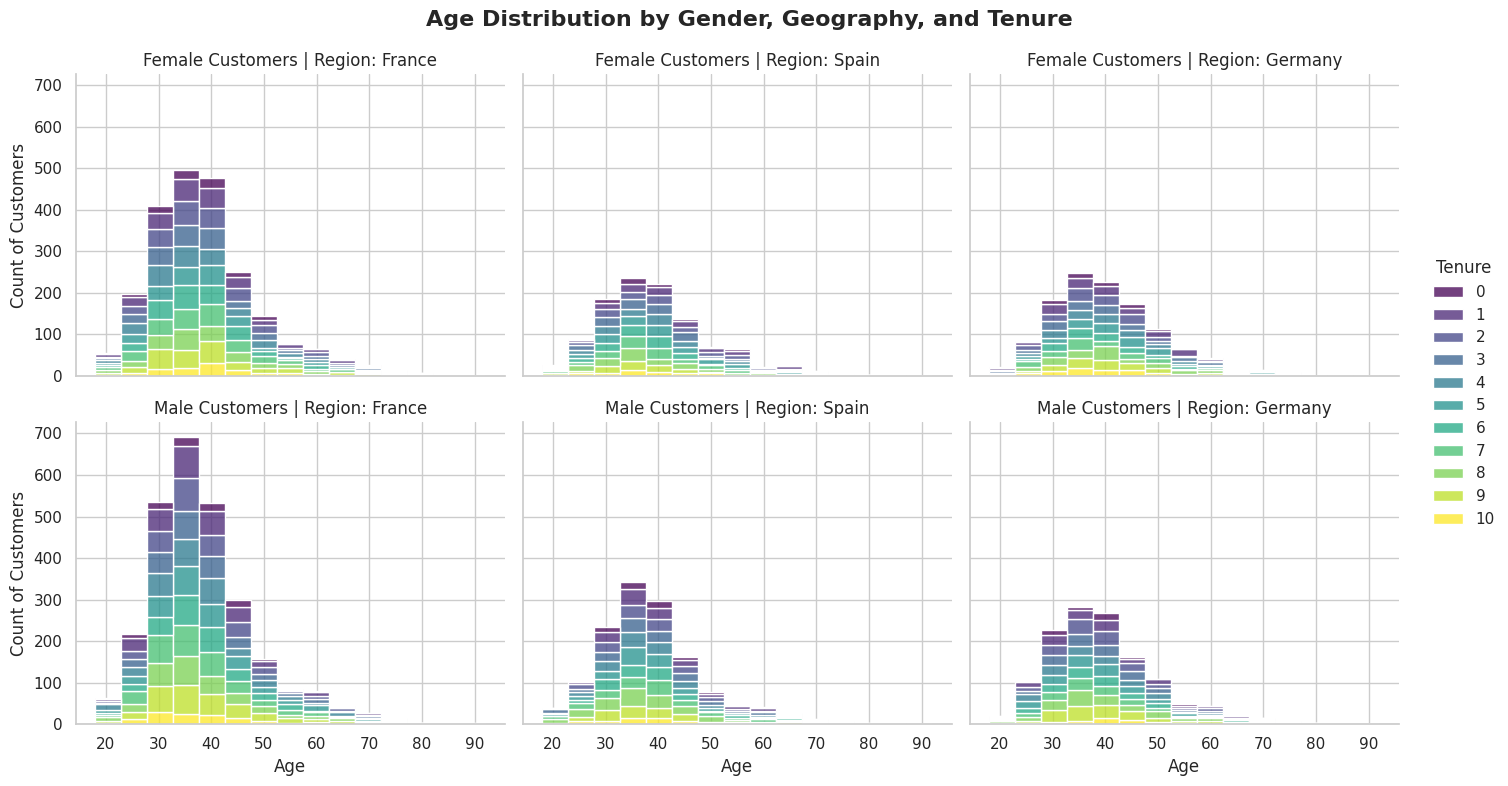

In [12]:
#Provide your answer with clear documentation that demonstrate a proper understanding of how the code works.

import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a faceted grid of histograms
# Row = Gender, Col = Geography, Hue = Tenure (to see tenure groups within the age distributions)
g = sns.displot(
    data=churn,
    x="Age",
    hue="Tenure",
    row="Gender",
    col="Geography",
    kind="hist",
    multiple="stack",    # Stacks the tenure bins so you can see the total age distribution clearly
    palette="viridis",   # A clean, sequential color palette for continuous/numeric categories like Tenure
    bins=15,             # Adjust this number to change the granularity of the Age bins
    height=4,
    aspect=1.2
)

# Optimize titles and spacing
g.set_titles(row_template="{row_name} Customers", col_template="Region: {col_name}")
g.set_axis_labels("Age", "Count of Customers")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Age Distribution by Gender, Geography, and Tenure", fontsize=16, fontweight='bold')

plt.show()

Adjusting the number of bins to match the number of unique Tenure values offers a view of age distribution that aligns with how long customers have been with the service. This can reveal patterns in age relative to customer tenure across different regions.

## **Bar Chart**

### What is a bar chart?
A bar chart is a type of graph used to display and compare the frequency, total, or average values of categorical data values. It consists of rectangular bars, with the height or length of each bar representing the value of the data for a specific category. Bar charts are used to compare data between categories, and to visualise patterns, trends, and relationships in data.

### Advantages
* Extremely easy to interpret
* Allows us to compare values within a categorical variable
* Can be placed on the same figure as other visualisations a scatterplot for added interpretability

### Disadvantages
* When the differences between categories are small, bar plots become difficult to interpret, as the bars then become to similar in size and thus hard to distinguish the value difference between them
* Perhaps overly simplified. This can be viewed as both an advantage and disadvantage

### The Task

Suppose we wanted to get the average of the `CreditScore` variable per country

We'll use `pandas` functionality to find the average credit score per country and create a dataframe of the results. We'll do it using `groupby` functionality:

```
gb = churn.groupby('Geography')['CreditScore'].mean().sort_values(ascending=True).reset_index()
```

This creates the following table:


<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Geography</th>
      <th>CreditScore</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>France</td>
      <td>649.668329</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Spain</td>
      <td>651.333872</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Germany</td>
      <td>651.453567</td>
    </tr>
  </tbody>
</table>


In [ ]:
gb = churn.groupby('Geography')['CreditScore'].mean().sort_values(ascending=True).reset_index()

fig = px.bar(gb, x='Geography', y='CreditScore', title='Average Credit Score by Geography')
fig.show()

### **Your Turn**

* Create a stacked bar chart that shows the average credit score by geography, further divided by gender. This will help in understanding how the average credit score distribution varies not only across geographies but also between genders within each region.

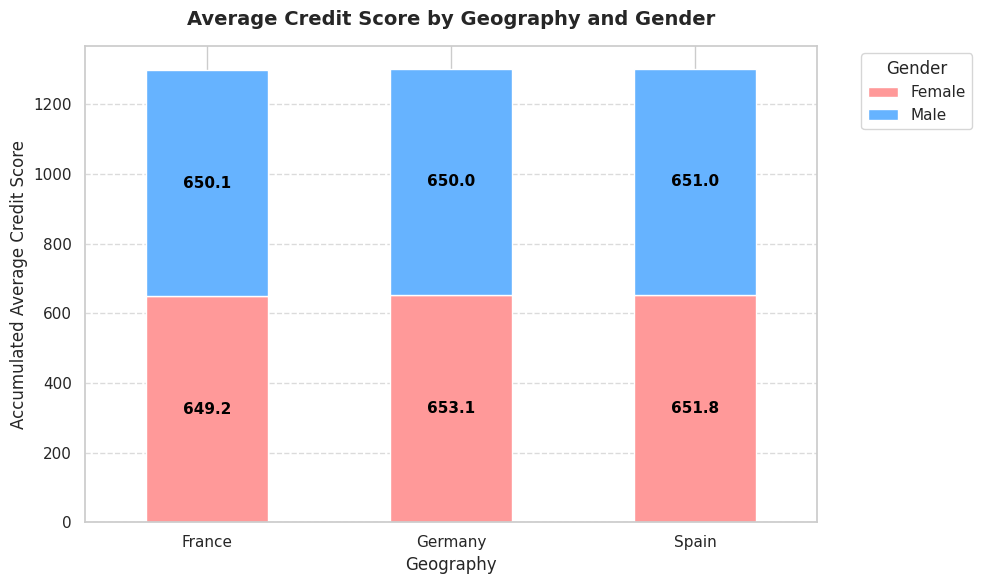

In [14]:
#Provide your answer with clear documentation that demonstrate a proper understanding of how the code works.

import pandas as pd
import matplotlib.pyplot as plt

# 1. Group by Geography & Gender, then calculate the mean CreditScore
avg_credit = churn.groupby(['Geography', 'Gender'])['CreditScore'].mean().unstack()

# 2. Plotting the stacked bar chart
ax = avg_credit.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999', '#66b3ff'])

# 3. Customizing the plot to make it readable
plt.title('Average Credit Score by Geography and Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Geography', fontsize=12)
plt.ylabel('Accumulated Average Credit Score', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Add data labels inside the bars to show the true average for each segment
for containers in ax.containers:
    labels = [f'{val:.1f}' for val in containers.datavalues]
    ax.bar_label(containers, labels=labels, label_type='center', fontsize=11, color='black', weight='bold')

# Move legend out of the way
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Submission
When you are ready to submit please go to `File` -> `Print` -> `Print PDF` and then upload and submit in the Campus Online.

Please save your file to GitHub via: `File` -> `Save a copy in GitHub`